In [36]:

import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
# from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt

import math
import plotly.express as px


In [37]:
df = pd.read_csv("data/papers.csv")
total_papers = len(df)
df.columns


Index(['Title', 'Database', 'Year', 'Month', 'Journal', 'Paper Type',
       'Data Source', 'Data Country', 'Data Domain', 'Data Language',
       'Data Availability', 'Link to Data', 'Data Details', 'Size',
       'Number of Prompts', 'Medical Application', 'Task Type', 'Topic',
       'Note', 'Bias Evaluation Metric', 'Bias Definition', 'Conclusions',
       'Race / Ethnic Bias', 'Language Bias', 'Age Bias', 'Gender Bias',
       'Other Bias', 'LGBTQ+ Bias', 'Disability Bias',
       'Geography / Cultural Bias', 'Evaluated LLMs',
       'Reference Standard \n(Human / Model / System / Physician)',
       'Patient Inclusion\n(Yes / No)', 'Has Debiasing',
       'Debias - Focus\n(Data/Train/Inference)', 'Debias-details'],
      dtype='str')

In [38]:
language_groups_lst = df["Language Bias"].tolist()


In [39]:
language_groups_freqs = defaultdict(int)

for s in language_groups_lst:
    
    if isinstance(s, float):
        language_groups_freqs[str(s)] += 1
        continue
    
    s = s.strip().lower()
    s = s.replace("_", " ")
    
    if s == "no":
        language_groups_freqs[s] += 1
        continue
    
    match = re.search(r'\((.*?)\)', s)
    if not match:
        continue   # skip malformed rows safely
    
    items = match.group(1)   # <-- only inside parentheses
    languages = [lang.strip() for lang in items.split(',')]
    
    for language in languages:
        language_groups_freqs[language] += 1

        

In [40]:
for k, v in language_groups_freqs.items():
    print(k, v)

no 47
chinese 1
english 5
arabic 2
spanish 2
non-arabic 1
aave 1
standard english 1
traditional chinese 1
simplified chinese 1
polish 1
saudi arabic 1
egyptian arabic 1
lebanese arabic 1
moroccan arabic 1


In [41]:
# del language_groups_freqs["no"]

# language_groups_freqs["english"] += language_groups_freqs["aave"]
# del language_groups_freqs["aave"]

# language_groups_freqs["arabic"] += 1
# del language_groups_freqs["saudi arabic"]
# del language_groups_freqs["egyptian arabic"]
# del language_groups_freqs["lebanese arabic"]
# del language_groups_freqs["moroccan arabic"]

# language_groups_freqs["portuguese"] = 1
# del language_groups_freqs["brazilian portuguese"]



language_groups_freqs = dict(
    sorted(
        language_groups_freqs.items(), 
        key=lambda item: item[1],
        reverse=True
    )[:20]
)

# bar_graph_language_groups_freqs = dict(
#     sorted(
#         bar_graph_language_groups_freqs.items(), 
#         key=lambda item: item[1],
#         reverse=True
#     )
# )

# bar_graph_language_groups_freqs.keys()

In [42]:
# rows = []

# for lang, countries in language_to_countries.items():
#     freq = language_groups_freqs.get(lang, 0)
    
#     for c in countries:
#         rows.append({
#             "country": c,
#             "language": lang,
#             "value": freq
#         })

# df = pd.DataFrame(rows)
# df_country = df.groupby("country").agg({
#     "value": "max",
#     "language": "first"  # optional (just for hover)
# }).reset_index()

In [43]:
# plt.figure()

# languages = list(bar_graph_language_groups_freqs.keys())
# counts = list(bar_graph_language_groups_freqs.values())

# bars = plt.bar(languages, counts)

# for i, count in enumerate(counts):
#     percent = (count / total_papers) * 100
#     plt.text(i, count, f"{percent:.1f}%",
#              ha='center', va='bottom')

# plt.xticks(rotation=45, ha='right')
# plt.xlabel("Language")
# plt.ylabel("Frequency")
# plt.ylim((0, 16))
# plt.title("Language Frequency Distribution")
# plt.tight_layout()
# plt.show()

In [44]:
# for idx in range(len(languages)):
#     print(languages[idx], counts[idx])

In [45]:
# racial_groups_lst = df["Racial Bias"].tolist()

# racial_groups_freqs = defaultdict(int)

# for s in racial_groups_lst:
    
#     if isinstance(s, float):
#         racial_groups_freqs[str(s)] += 1
#         continue
    
#     s = s.strip().lower()
#     s = s.replace("_", " ")
    
#     if s == "no":
#         racial_groups_freqs[s] += 1
#         continue
    
#     match = re.search(r'\((.*?)\)', s)
#     if not match:
#         continue
    
#     items = match.group(1) 
#     races = [race.strip() for race in items.split(',')]
    
#     for race in races:
#         racial_groups_freqs[race] += 1

In [46]:
# racial_groups_freqs

# del racial_groups_freqs["no"]
# del racial_groups_freqs["e.g."]
# del racial_groups_freqs["non-soc"]
# del racial_groups_freqs["soc"]
# del racial_groups_freqs["undetermined"]
# del racial_groups_freqs["racial groups based on cohort metadata"]
# del racial_groups_freqs["non-white"]
# del racial_groups_freqs["race categories reported in the study"]

# # asian
# racial_groups_freqs["asian"] += racial_groups_freqs["east asian"]
# racial_groups_freqs["asian"] += racial_groups_freqs["and east asian"]
# racial_groups_freqs["asian"] += racial_groups_freqs["south asian"]
# racial_groups_freqs["asian"] += racial_groups_freqs["asian american"]
# del racial_groups_freqs["and east asian"]
# del racial_groups_freqs["east asian"]
# del racial_groups_freqs["south asian"]
# del racial_groups_freqs["asian american"]

# # african american
# racial_groups_freqs["black"] += racial_groups_freqs["black or african american"]
# racial_groups_freqs["black"] += racial_groups_freqs["african american"]
# racial_groups_freqs["black"] += racial_groups_freqs["black vs others"]
# racial_groups_freqs["black"] += racial_groups_freqs["non hispanic black"]
# del racial_groups_freqs["black or african american"]
# del racial_groups_freqs["african american"]
# del racial_groups_freqs["black vs others"]
# del racial_groups_freqs["non hispanic black"]

# # native american
# racial_groups_freqs["native american"] += racial_groups_freqs["american indian/native american"]
# racial_groups_freqs["native american"] += racial_groups_freqs["american indian"]
# racial_groups_freqs["native american"] += racial_groups_freqs["american indian or alaska native"]
# del racial_groups_freqs["american indian/native american"]
# del racial_groups_freqs["american indian"]
# del racial_groups_freqs["american indian or alaska native"]

# # hispanic
# racial_groups_freqs["hispanic"] += racial_groups_freqs["hispanic or latino"]
# racial_groups_freqs["hispanic"] += racial_groups_freqs["latinx"]
# racial_groups_freqs["hispanic"] += racial_groups_freqs["hispanic or latino americans"]
# racial_groups_freqs["hispanic"] += racial_groups_freqs["hispanic or latino or of spanish origin"]
# racial_groups_freqs["hispanic"] += racial_groups_freqs["latino"]
# del racial_groups_freqs["hispanic or latino"]
# del racial_groups_freqs["latinx"]
# del racial_groups_freqs["hispanic or latino americans"]
# del racial_groups_freqs["hispanic or latino or of spanish origin"]
# del racial_groups_freqs["latino"]

# # pacifical islander
# racial_groups_freqs["pacific islander"] += racial_groups_freqs["native hawaiian or other pacific islander"]
# racial_groups_freqs["pacific islander"] += racial_groups_freqs["native hawaiian"]
# del racial_groups_freqs["native hawaiian or other pacific islander"]
# del racial_groups_freqs["native hawaiian"]

# # white
# racial_groups_freqs["white"] += racial_groups_freqs["caucasian"]
# racial_groups_freqs["white"] += racial_groups_freqs["european american"]
# racial_groups_freqs["white"] += racial_groups_freqs["non hispanic white"]
# del racial_groups_freqs["caucasian"]
# del racial_groups_freqs["european american"]
# del racial_groups_freqs["non hispanic white"]

In [47]:
# racial_groups_freqs = dict(
#     sorted(
#         racial_groups_freqs.items(), 
#         key=lambda item: item[1],
#         reverse=True
#     )[:7]
# )

# plt.figure()

# races = list(racial_groups_freqs.keys())
# counts = list(racial_groups_freqs.values())

# bars = plt.bar(races, counts)

# for i, count in enumerate(counts):
#     percent = (count / total_papers) * 100
#     plt.text(i, count, f"{percent:.1f}%",
#              ha='center', va='bottom')

# plt.xticks(rotation=45, ha='right')
# plt.xlabel("Racial Group")
# plt.ylabel("Frequency")
# plt.ylim((0, 50))
# plt.title("Frequency of Study for Different Racial Groups")
# plt.tight_layout()
# plt.show()

/var/folders/04/2hwl1j9x5yl1hdpnd9k3jlqw0000gn/T/ipykernel_84633/3377006272.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(m + " 1 " + y.astype("Int64").astype(str), errors="coerce")


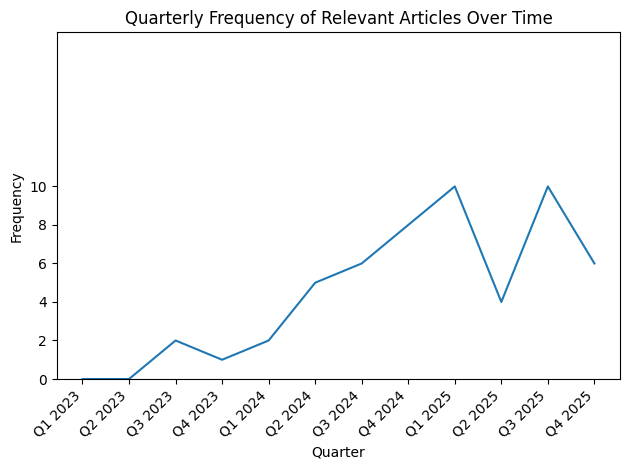

In [48]:
m = (df["Month"]
     .astype(str)
     .str.strip()
     .str.lower()
     .replace({"jun": "june", "jul": "july", "aug": "august",
               "sep": "september", "oct": "october", "dec": "december"})
)

m = m.mask(m.isin(["nan", "unsure", "unclear"]))
y = pd.to_numeric(df["Year"], errors="coerce")
df["date"] = pd.to_datetime(m + " 1 " + y.astype("Int64").astype(str), errors="coerce")
df = df.dropna(subset=["date"])

counts = (
    df.groupby(df["date"].dt.to_period("Q"))
      .size()
      .sort_index()
)

full_range = pd.period_range(
    start="2023Q1",   # force inclusion
    end=counts.index.max(),
    freq="Q"
)

counts = counts.reindex(full_range, fill_value=0)

counts.index = [f"Q{p.quarter} {p.year}" for p in counts.index]

plt.figure()
plt.plot(counts.index, counts.values)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Quarter")
plt.ylabel("Frequency")
plt.yticks(np.arange(0, max(counts.values) + 2, 2))
plt.title("Quarterly Frequency of Relevant Articles Over Time")
plt.ylim((0, 18))
plt.tight_layout()
plt.show()

In [49]:
llms_lst = df["Evaluated LLMs"].dropna().tolist()

freq_mp = Counter(
    model.strip()
    for entry in llms_lst
    for model in entry.split(",")
)

In [50]:
# ChatGPT
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3.5']
freq_mp["ChatGPT"] += freq_mp['GPT-4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4.0']
freq_mp["ChatGPT"] += freq_mp['GPT-4o-mini']
freq_mp["ChatGPT"] += freq_mp['GPT-4o']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4o']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3.5-turbo']
freq_mp["ChatGPT"] += freq_mp['GPT-4 Turbo']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5 Turbo']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 3.5']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 4.0']
freq_mp["ChatGPT"] += freq_mp['OpenAI’s GPT-4']
freq_mp["ChatGPT"] += freq_mp['OpenAI’s ChatGPT May 12 and\nAugust 3 versions']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5-Turbo']
freq_mp["ChatGPT"] += freq_mp['COT-ChatGPT-4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4.5']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 4o']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3.5-Turbo']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5-turbo']
freq_mp["ChatGPT"] += freq_mp['GPT3.5-turbo']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-2']
freq_mp["ChatGPT"] += freq_mp['ChatGPT4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT3.5']
freq_mp["ChatGPT"] += freq_mp['GPT-4-o']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3']
freq_mp["ChatGPT"] += freq_mp['GPT‑2']
freq_mp["ChatGPT"] += freq_mp['ChatGPT (3.5 versions May 12']
freq_mp["ChatGPT"] += freq_mp['GPT‑4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 4o']
freq_mp["ChatGPT"] += freq_mp["ChatGPT-3.5-Turbo"]
freq_mp["ChatGPT"] += freq_mp["ChatGPT GPT-4"]
freq_mp["ChatGPT"] += freq_mp["GPT-3"]
freq_mp["ChatGPT"] += freq_mp["ChatGPT (GPT-3.5 version)"]
freq_mp["ChatGPT"] += freq_mp["ChatGPT (unspecified version)"]
freq_mp["ChatGPT"] += freq_mp["GPT-2"]
freq_mp["ChatGPT"] += freq_mp["ChatGPT‑4o"]
freq_mp["ChatGPT"] += freq_mp["Agent-ChatGPT-4"]
freq_mp["ChatGPT"] += freq_mp["GPT-3.5-Turbo and GPT-4"] + 1
freq_mp["ChatGPT"] += freq_mp['ChatGPT GPT‑3.5‑Turbo‑0301']

del freq_mp['ChatGPT-4']
del freq_mp['ChatGPT-3.5']
del freq_mp['GPT-4']
del freq_mp['ChatGPT-4.0']
del freq_mp['GPT-4o-mini']
del freq_mp['GPT-4o']
del freq_mp['ChatGPT-4o']
del freq_mp['GPT-3.5']
del freq_mp['ChatGPT-3.5-turbo']
del freq_mp['GPT-4 Turbo']
del freq_mp['GPT-3.5 Turbo']
del freq_mp['ChatGPT 3.5']
del freq_mp['ChatGPT 4.0']
del freq_mp['OpenAI’s GPT-4']
del freq_mp['OpenAI’s ChatGPT May 12 and\nAugust 3 versions']
del freq_mp['GPT-3.5-Turbo']
del freq_mp['COT-ChatGPT-4']
del freq_mp['ChatGPT-4.5']
del freq_mp['GPT-3.5-turbo']
del freq_mp['GPT3.5-turbo']
del freq_mp['ChatGPT-2']
del freq_mp['ChatGPT4']
del freq_mp['ChatGPT3.5']
del freq_mp['GPT-4-o']
del freq_mp['ChatGPT-3']
del freq_mp['GPT‑2']
del freq_mp['ChatGPT (3.5 versions May 12']
del freq_mp['GPT‑4']
del freq_mp['ChatGPT 4o']
del freq_mp["ChatGPT-3.5-Turbo"]
del freq_mp["ChatGPT GPT-4"]
del freq_mp["GPT-3"]
del freq_mp["ChatGPT (GPT-3.5 version)"]
del freq_mp["ChatGPT (unspecified version)"]
del freq_mp["GPT-2"]
del freq_mp["ChatGPT‑4o"]
del freq_mp["Agent-ChatGPT-4"]
del freq_mp["GPT-3.5-Turbo and GPT-4"]
del freq_mp['ChatGPT GPT‑3.5‑Turbo‑0301']


# Gemini
freq_mp["Gemini"] += freq_mp['Gemini 1.5 Flash']
freq_mp["Gemini"] += freq_mp['Gemini-1.5-Flash']
freq_mp["Gemini"] += freq_mp['Gemini-1.0-pro']
freq_mp["Gemini"] += freq_mp['Gemini-3.5-Flash)']
freq_mp["Gemini"] += freq_mp["Gemini 1.5 Pro"]

del freq_mp['Gemini 1.5 Flash']
del freq_mp['Gemini-1.5-Flash']
del freq_mp['Gemini-1.0-pro']
del freq_mp['Gemini-3.5-Flash)']
del freq_mp["Gemini 1.5 Pro"]


# Llama
freq_mp["Llama"] += freq_mp["Llama-2 (13b)"]
freq_mp["Llama"] += freq_mp["Llama-2 (7b)"]
freq_mp["Llama"] += freq_mp['Llama-3.1-8B']
freq_mp["Llama"] += freq_mp['Llama-3.1-70B']
freq_mp["Llama"] += freq_mp['Llama3-70b']
freq_mp["Llama"] += freq_mp['LLama3-70B']
freq_mp["Llama"] += freq_mp['Llama3.1-403B']
freq_mp["Llama"] += freq_mp['Llama3.1-403B']
freq_mp["Llama"] += freq_mp['LLaMA-2']
freq_mp["Llama"] += freq_mp['COT-LLaMA-3 60 56 52 66\nSFT-LoRA']
freq_mp["Llama"] += freq_mp['Llama-3-70b']
freq_mp["Llama"] += freq_mp['Llama-3.1-Instruct-8B']
freq_mp["Llama"] += freq_mp['Llama-3.1-Instruct-70B']
freq_mp["Llama"] += freq_mp['Llama-3.2-3B Instruct']
freq_mp["Llama"] += freq_mp['Llama3-Med42-8B']
freq_mp["Llama"] += freq_mp["Llama3-8B"]
freq_mp["Llama"] += freq_mp["and Llama3-8B"]
freq_mp["Llama"] += freq_mp["LLaMA-3.2-3B-Instruct"]
freq_mp["Llama"] += freq_mp["Llama-3.1-8B-Instruct"]
freq_mp["Llama"] += freq_mp["LLaMA-3.2"]
freq_mp["Llama"] += freq_mp["Llama3-I-70B"]
freq_mp["Llama"] += freq_mp["Llama3-I-8B"]
freq_mp["Llama"] += freq_mp["LLaMA-3.2"]
freq_mp["Llama"] += freq_mp["Llama 2-13B"]
freq_mp["Llama"] += freq_mp["LLaMA"]

del freq_mp["Llama-2 (13b)"]
del freq_mp["Llama-2 (7b)"]
del freq_mp['Llama-3.1-8B']
del freq_mp['Llama-3.1-70B']
del freq_mp['Llama3-70b']
del freq_mp['LLama3-70B']
del freq_mp['Llama3.1-403B']
del freq_mp['Llama3.1-403B']
del freq_mp['LLaMA-2']
del freq_mp['COT-LLaMA-3 60 56 52 66\nSFT-LoRA']
del freq_mp['Llama-3-70b']
del freq_mp['Llama-3.1-Instruct-8B']
del freq_mp['Llama-3.1-Instruct-70B']
del freq_mp['Llama-3.2-3B Instruct']
del freq_mp['Llama3-Med42-8B']
del freq_mp["Llama3-8B"]
del freq_mp["and Llama3-8B"]
del freq_mp["LLaMA-3.2-3B-Instruct"]
del freq_mp["Llama-3.1-8B-Instruct"]
del freq_mp["Llama3-I-70B"]
del freq_mp["Llama3-I-8B"]
del freq_mp["LLaMA-3.2"]
del freq_mp["Llama 2-13B"]
del freq_mp["LLaMA"]


# Claude  
freq_mp["Claude"] += freq_mp["COT-Claude-3"]
freq_mp["Claude"] += freq_mp["Anthropic’s Claude May 15 and\nAugust 3 versions"]
freq_mp["Claude"] += freq_mp["Claude 3 Haiku"]
freq_mp["Claude"] += freq_mp["Haiku"]
freq_mp["Claude"] += freq_mp["Claude-3-5-sonnet-20240620"]
freq_mp["Claude"] += freq_mp["Claude (May 15"]
freq_mp["Claude"] += freq_mp["Claude 3.5 Sonnet"]

del freq_mp["COT-Claude-3"]
del freq_mp["Anthropic’s Claude May 15 and\nAugust 3 versions"]
del freq_mp["Claude 3 Haiku"]
del freq_mp["Haiku"]
del freq_mp["Claude-3-5-sonnet-20240620"]
del freq_mp["Claude-3.5-Sonnet"]
del freq_mp["Claude (May 15"]
del freq_mp["Claude 3.5 Sonnet"]


# Qwen
freq_mp["Qwen"] += freq_mp['Qwen2-7B']
freq_mp["Qwen"] += freq_mp['Qwen2-72B']
freq_mp["Qwen"] += freq_mp['Qwen-turbo']
freq_mp["Qwen"] += freq_mp['Qwen1.5-72b']
freq_mp["Qwen"] += freq_mp['Qwen1.5-70B-Chat']
freq_mp["Qwen"] += freq_mp['Qwen1.5-70B-Chat']
freq_mp["Qwen"] += freq_mp['Qwen1.5-7B-Chat']
freq_mp["Qwen"] += freq_mp['Qwen1.5-7B-SFT']
freq_mp["Qwen"] += freq_mp['Qwen2.5-Instruct-7B and Qwen2.5-Instruct-72B']
freq_mp["Qwen"] += freq_mp['Qwen-14B']

del freq_mp['Qwen2-7B']
del freq_mp['Qwen2-72B']
del freq_mp['Qwen-turbo']
del freq_mp['Qwen1.5-72b']
del freq_mp['Qwen1.5-70B-Chat']
del freq_mp['Qwen1.5-70B-Chat']
del freq_mp['Qwen1.5-7B-Chat']
del freq_mp['Qwen1.5-7B-SFT']
del freq_mp['Qwen2.5-Instruct-7B and Qwen2.5-Instruct-72B']
del freq_mp['Qwen-14B']

# Mistral
freq_mp["Mistral"] += freq_mp["Mistral (7b)"]
freq_mp["Mistral"] += freq_mp["Mistral-7B-v0.1"]
freq_mp["Mistral"] += freq_mp["Mistral-7B"]
freq_mp["Mistral"] += freq_mp["Mistral-I-7B"]
freq_mp["Mistral"] += freq_mp["mistralai/Mistral-Small-Instruct-2409"]
freq_mp["Mistral"] += freq_mp["Mistral-Large-Instruct-2407"]
freq_mp["Mistral"] += freq_mp["Mistral-del"]

del freq_mp["Mistral (7b)"]
del freq_mp["Mistral-7B-v0.1"]
del freq_mp["Mistral-7B"]
del freq_mp["Mistral-I-7B"]
del freq_mp["mistralai/Mistral-Small-Instruct-2409"]
del freq_mp["Mistral-Large-Instruct-2407"]
del freq_mp["Mistral-del"]

# Gemma
freq_mp["Gemma"] += freq_mp["Gemma-2-27B"]
freq_mp["Gemma"] += freq_mp["Gemma-2-9B-it"]
freq_mp["Gemma"] += freq_mp["Gemma-3"]

del freq_mp["Gemma-2-27B"]
del freq_mp["Gemma-2-9B-it"]
del freq_mp["Gemma-3"]

# Phi
freq_mp["Phi"] += freq_mp["Phi-3.5-mini-instruct"]
freq_mp["Phi"] += freq_mp["Phi-3-medium-128k-instruct"]

del freq_mp["Phi-3.5-mini-instruct"]
del freq_mp["Phi-3-medium-128k-instruct"]

# BioMistral
freq_mp["BioMistral"] += freq_mp["BioMistral-7B"]

del freq_mp["BioMistral-7B"]

# Bard 
freq_mp["Bard"] += freq_mp["Google’s Bard May 18\nand August 3 version"]
freq_mp["Bard"] += freq_mp["Google-Bard"]
freq_mp["Bard"] += freq_mp["Bard (May 18"]
freq_mp["Bard"] += freq_mp["Google Bard"]

del freq_mp["Google’s Bard May 18\nand August 3 version"]
del freq_mp["Google-Bard"]
del freq_mp["Bard (May 18"]
del freq_mp["Google Bard"]


# Bing
freq_mp["Bing"] += freq_mp["Bing AI"]
freq_mp["Bing"] += freq_mp["Bing-Chat"]
freq_mp["Bing"] += freq_mp["Bing-Chat"]
freq_mp["Bing"] += freq_mp["BingChat"]
freq_mp["Bing"] += freq_mp["Microsoft Bing"]
freq_mp["Bing"] += freq_mp["Microsoft’s Bing A.I. Image Creator"]

del freq_mp["Bing AI"]
del freq_mp["Bing-Chat"]
del freq_mp["Bing-Chat"]
del freq_mp["BingChat"]
del freq_mp["Microsoft Bing"]
del freq_mp["Microsoft’s Bing A.I. Image Creator"]


# Baichuan
freq_mp["Baichuan"] += freq_mp["Baichuan2-turbo"]

del freq_mp["Baichuan2-turbo"]


# Olmo
freq_mp["Olmo"] += freq_mp["OLMo-7B-Instruct"]
freq_mp["Olmo"] += freq_mp["and OLMo-2-0325-32B-Instruct"]

del freq_mp["OLMo-7B-Instruct"]
del freq_mp["and OLMo-2-0325-32B-Instruct"]


freq_mp["OpenBioLLM"] += freq_mp["OpenBioLLM-8B"]
freq_mp["OpenBioLLM"] += freq_mp["OpenBioLLM-70B"]

del freq_mp["OpenBioLLM-8B"]
del freq_mp["OpenBioLLM-70B"]


# UltraMedicalLLM 
freq_mp["UltraMedicalLLM"] += freq_mp["UltraMedicalLLM-8B"]
freq_mp["UltraMedicalLLM"] += freq_mp["UltraMedicalLLM-70B"]

del freq_mp["UltraMedicalLLM-8B"]
del freq_mp["UltraMedicalLLM-70B"]


# Yi-Chat
freq_mp["Yi-Chat"] += freq_mp["Yi-Chat-34B"]
freq_mp["Yi-Chat"] += freq_mp["Yi-Chat-34B"]
freq_mp["Yi-Chat"] += freq_mp["Yi-34B"]
freq_mp["Yi-Chat"] += freq_mp["Yi-Chat-6B"]

del freq_mp["Yi-Chat-34B"]
del freq_mp["Yi-Chat-34B"]
del freq_mp["Yi-34B"]
del freq_mp["Yi-Chat-6B"]


# HuatuoGPT
freq_mp["HuatuoGPT"] += freq_mp["HuatuoGPT2-34B"]
freq_mp["HuatuoGPT"] += freq_mp["HuatuoGPT2-13B"]

del freq_mp["HuatuoGPT2-34B"]
del freq_mp["HuatuoGPT2-13B"]

# Ziya
freq_mp["Ziya"] += freq_mp["Ziya-7B"]

del freq_mp["Ziya-7B"]


# Meditron
freq_mp["Meditron"] += freq_mp["Meditron-3-8B"]
freq_mp["Meditron"] += freq_mp["Meditron-3-70B"]

del freq_mp["Meditron-3-8B"]
del freq_mp["Meditron-3-70B"]


# AceGPT
freq_mp["AceGPT"] += freq_mp["AceGPT-7B"]
freq_mp["AceGPT"] += freq_mp["AceGPT-13B"]

del freq_mp["AceGPT-7B"]
del freq_mp["AceGPT-13B"]

In [51]:
freq_mp

Counter({'ChatGPT': 60,
         'Llama': 22,
         'Qwen': 9,
         'Gemini': 7,
         'Mistral': 7,
         'Claude': 4,
         'Gemma': 4,
         'BioMistral': 4,
         'Bing': 4,
         'Bard': 3,
         'Yi-Chat': 3,
         'Ziya': 2,
         'Baichuan': 2,
         'Phi': 2,
         'Olmo': 2,
         'OpenBioLLM': 2,
         'UltraMedicalLLM': 2,
         'HuatuoGPT': 2,
         'Meditron': 2,
         'AceGPT': 2,
         'Stanford Medicine Secure GPT': 1,
         'Med-PaLM2': 1,
         'Med-PaLM': 1,
         'ERNIE': 1,
         'DALL-E 3': 1,
         'Firefly 2': 1,
         'Stable Diffusion 2.1': 1,
         'and Midjourney 5.2': 1,
         'MentaLLaMA': 1,
         'LLM-based program previously developed and tested at Cedars-Sinai Medical Center': 1,
         'GloVe': 1,
         'BERT': 1,
         'LegalBERT': 1,
         'BioBERT': 1,
         'BioGPT': 1,
         'Erine-lite-8k': 1,
         'ChexPert': 1,
         'RadReportAnnotato

Counter({'ChatGPT': 60, 'Llama': 22, 'Qwen': 9, 'Gemini': 7, 'Mistral': 7, 'Claude': 4, 'Gemma': 4, 'BioMistral': 4, 'Bing': 4, 'Bard': 3, 'Yi-Chat': 3, 'Ziya': 2, 'Baichuan': 2, 'Phi': 2, 'Olmo': 2, 'OpenBioLLM': 2, 'UltraMedicalLLM': 2, 'HuatuoGPT': 2, 'Meditron': 2, 'AceGPT': 2, 'Stanford Medicine Secure GPT': 1, 'Med-PaLM2': 1, 'Med-PaLM': 1, 'ERNIE': 1, 'DALL-E 3': 1, 'Firefly 2': 1, 'Stable Diffusion 2.1': 1, 'and Midjourney 5.2': 1, 'MentaLLaMA': 1, 'LLM-based program previously developed and tested at Cedars-Sinai Medical Center': 1, 'GloVe': 1, 'BERT': 1, 'LegalBERT': 1, 'BioBERT': 1, 'BioGPT': 1, 'Erine-lite-8k': 1, 'ChexPert': 1, 'RadReportAnnotator': 1, 'cTakes': 1, 'BERT-Base': 1, 'PubMedBERT': 1, 'MOBERT': 1, '1965BERT': 1, 'Jais-13B': 1, '30 LLMs': 1, 'see paper': 1, 'GPT-4 and similar frontier LLMs': 1, 'and similar models': 1, 'Alpaca (7b)': 1, 'Clin-Camel (13b)': 1, 'Asclepius (7b)': 1, 'MedAlpaca (7b)': 1, 'Taiyi': 1, 'and MedicalGPT. ChiMed-GPT': 1, 'Bch-Chat-13B': 

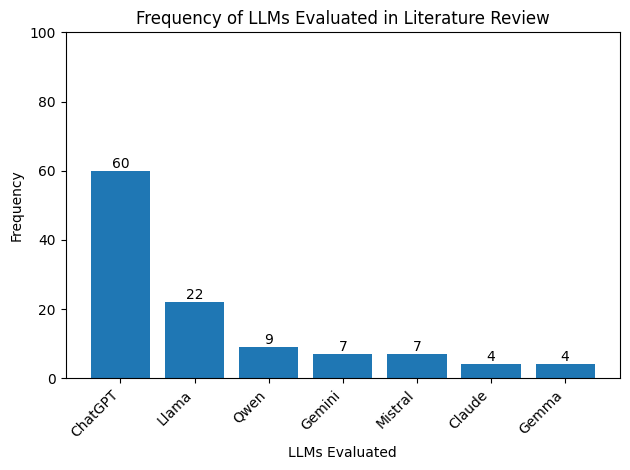

In [52]:
print(freq_mp)

llms_freqs = dict(
    sorted(
        freq_mp.items(), 
        key=lambda item: item[1],
        reverse=True
    )[:7]
)

plt.figure()

llms = list(llms_freqs.keys())
counts = list(llms_freqs.values())

bars = plt.bar(llms, counts)

# Show counts only
for i, count in enumerate(counts):
    plt.text(i, count, str(count),
             ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel("LLMs Evaluated")
plt.ylabel("Frequency")
plt.ylim((0, 100))
plt.title("Frequency of LLMs Evaluated in Literature Review")
plt.tight_layout()
plt.show()

In [53]:
llms_date = {}

llms_count = {
    "GPT 2": 0, "GPT 3": 0, "GPT 4": 0, "Gemini 1": 0, "Llama 2": 0, 
    "Llama 3": 0, "Claude 3": 0, "Qwen 1": 0, "Mistral": 0 
}

months = [
    "January", "February", "March", "April", "May", "June", "July", 
    "August", "September", "October", "November", "December"
]

for year in [2023, 2024, 2025]:
    for month in months:
        llms_date[f"{month} {year}"] = {
            "GPT 2": 0, "GPT 3": 0, "GPT 4": 0, "Gemini 1": 0, "Llama 2": 0,
            "Llama 3": 0, "Claude 3": 0, "Qwen 1": 0, "Mistral": 0
        }

In [54]:
gpt_2 = [
    "ChatGPT-2", "GPT-2", "GPT-2",
]

gpt_3 = [
    "ChatGPT-3", "GPT-3", "ChatGPT3.5", "ChatGPT 3.5", "ChatGPT-3.5", "ChatGPT-3.5-turbo",
    "ChatGPT-3.5-Turbo", "ChatGPT GPT-3.5-Turbo-0301", "GPT-3.5", "GPT-3.5-turbo", 
    "GPT-3.5 Turbo", "GPT-3.5-Turbo", "GPT3.5-turbo", "ChatGPT (GPT-3.5 version)",
    "ChatGPT (3.5 versions May 12",
]

gpt_4 = [
    "ChatGPT-4", "ChatGPT-4.0", "ChatGPT 4.0", "ChatGPT4", "ChatGPT-4.5",
    "ChatGPT-4o", "ChatGPT 4o", "ChatGPT-4o", "GPT-4", "GPT-4", "GPT-4 Turbo",
    "GPT-4o", "GPT-4o-mini", "GPT-4-o", "OpenAI’s GPT-4", "ChatGPT GPT-4", 
    "COT-ChatGPT-4", "Agent-ChatGPT-4", "GPT-3.5-Turbo and GPT-4", 
]

gemini1 = [
    "Gemini 1.5 Flash", "Gemini-1.5-Flash", 'Gemini-1.0-pro', "Gemini 1.5 Pro"
]

gemini3 = [
    'Gemini-3.5-Flash'
]

llama_1 = [
    "LLaMA",
]

llama_2 = [
    "LLaMA-2", "Llama-2 (13b)", "Llama-2 (7b)", "Llama 2-13B",
]

llama_3 = [
    "Llama-3.1-8B", "Llama-3.1-70B", "Llama3-70b", "LLama3-70B", "Llama3.1-403B",
    "Llama-3-70b", "Llama-3.1-Instruct-8B", "Llama-3.1-Instruct-70B", "Llama-3.2-3B Instruct", 
    "Llama3-Med42-8B", "Llama3-8B", "and Llama3-8B", "LLaMA-3.2-3B-Instruct", 
    "Llama-3.1-8B-Instruct", "LLaMA-3.2", "Llama3-I-70B", "Llama3-I-8B", 
    "COT-LLaMA-3 60 56 52 66\nSFT-LoRA",
]

claude_3 = [
    "COT-Claude-3", "Claude 3 Haiku", "Haiku", "Claude-3-5-sonnet-20240620", 
    "Claude 3.5 Sonnet",
]

# Qwen 1
qwen_1 = [
    'Qwen-turbo', 'Qwen1.5-72b', 'Qwen1.5-70B-Chat', 'Qwen1.5-70B-Chat', 'Qwen1.5-7B-Chat',
    'Qwen1.5-7B-SFT', 'Qwen-14B',
]

# Mistral
mistral = [
    "Mistral (7b)", "Mistral-7B-v0.1", "Mistral-7B", "Mistral-I-7B", 
    "mistralai/Mistral-Small-Instruct-2409", "Mistral-Large-Instruct-2407", "Mistral-del",
]

In [55]:

df = pd.read_csv("data/papers.csv")

model_groups = {
    "GPT 2": gpt_2, "GPT 3": gpt_3, "GPT 4": gpt_4, "Gemini 1": gemini1, "Llama 2": llama_2, 
    "Llama 3": llama_3, "Claude 3": claude_3, "Qwen 1": qwen_1, "Mistral": mistral
}

count = 0 
for index, row in df.iterrows():
    paper_date = f'{row["Month"]} {row["Year"]}'
    if type(row["Evaluated LLMs"]) != str:
        continue
    
    models = [m.strip() for m in row["Evaluated LLMs"].split(",")]

    for model in models:
        for group_name, model_group in model_groups.items():
            if model in model_group:
                try:
                    print(model, group_name)
                    llms_date[paper_date][group_name] += 1
                except KeyError:
                    continue
                

Llama3-Med42-8B Llama 3
GPT-4o GPT 4
GPT-4o-mini GPT 4
ChatGPT-4 GPT 4
ChatGPT-4 GPT 4
Llama-3.1-8B Llama 3
Llama-3.1-70B Llama 3
GPT-4o GPT 4
GPT-4 GPT 4
Gemini 1.5 Flash Gemini 1
Claude 3 Haiku Claude 3
GPT-4o GPT 4
ChatGPT-3.5 GPT 3
ChatGPT-4.0 GPT 4
ChatGPT-4 GPT 4
ChatGPT-3.5 GPT 3
ChatGPT-4 GPT 4
ChatGPT-3.5 GPT 3
ChatGPT-4.0 GPT 4
ChatGPT-4 GPT 4
ChatGPT-4 GPT 4
GPT-4 GPT 4
GPT-4o-mini GPT 4
Gemini-1.5-Flash Gemini 1
Claude-3-5-sonnet-20240620 Claude 3
GPT-2 GPT 2
ChatGPT-3.5-turbo GPT 3
ChatGPT-4 GPT 4
Gemini-1.0-pro Gemini 1
Llama3-70b Llama 3
Qwen-turbo Qwen 1
ChatGPT-4 GPT 4
ChatGPT-3.5 GPT 3
ChatGPT-4o GPT 4
GPT-4 Turbo GPT 4
Haiku Claude 3
LLama3-70B Llama 3
Llama3.1-403B Llama 3
GPT-4o-mini GPT 4
COT-ChatGPT-4 GPT 4
COT-Claude-3 Claude 3
COT-LLaMA-3 60 56 52 66
SFT-LoRA Llama 3
Agent-ChatGPT-4 GPT 4
ChatGPT-4.0 GPT 4
ChatGPT-3.5-Turbo GPT 3
GPT-3.5 Turbo GPT 3
GPT-4 Turbo GPT 4
GPT-4o GPT 4
Gemini 1.5 Flash Gemini 1
and Llama3-8B Llama 3
GPT-4 GPT 4
Qwen1.5-72b Qwen 1
Cha

In [56]:
llms_date

{'January 2023': {'GPT 2': 0,
  'GPT 3': 0,
  'GPT 4': 0,
  'Gemini 1': 0,
  'Llama 2': 0,
  'Llama 3': 0,
  'Claude 3': 0,
  'Qwen 1': 0,
  'Mistral': 0},
 'February 2023': {'GPT 2': 0,
  'GPT 3': 0,
  'GPT 4': 0,
  'Gemini 1': 0,
  'Llama 2': 0,
  'Llama 3': 0,
  'Claude 3': 0,
  'Qwen 1': 0,
  'Mistral': 0},
 'March 2023': {'GPT 2': 0,
  'GPT 3': 0,
  'GPT 4': 0,
  'Gemini 1': 0,
  'Llama 2': 0,
  'Llama 3': 0,
  'Claude 3': 0,
  'Qwen 1': 0,
  'Mistral': 0},
 'April 2023': {'GPT 2': 0,
  'GPT 3': 0,
  'GPT 4': 0,
  'Gemini 1': 0,
  'Llama 2': 0,
  'Llama 3': 0,
  'Claude 3': 0,
  'Qwen 1': 0,
  'Mistral': 0},
 'May 2023': {'GPT 2': 0,
  'GPT 3': 0,
  'GPT 4': 0,
  'Gemini 1': 0,
  'Llama 2': 0,
  'Llama 3': 0,
  'Claude 3': 0,
  'Qwen 1': 0,
  'Mistral': 0},
 'June 2023': {'GPT 2': 0,
  'GPT 3': 0,
  'GPT 4': 0,
  'Gemini 1': 0,
  'Llama 2': 0,
  'Llama 3': 0,
  'Claude 3': 0,
  'Qwen 1': 0,
  'Mistral': 0},
 'July 2023': {'GPT 2': 0,
  'GPT 3': 0,
  'GPT 4': 0,
  'Gemini 1': 0,
  

https://github.com/lukes/ISO-3166-Countries-with-Regional-Codes/blob/master/all/all.csv

To find country codes for all the countries.

In [57]:
import matplotlib.ticker as ticker

df = pd.DataFrame.from_dict(llms_date, orient='index')
df.index = pd.to_datetime(df.index)

# Sort by time (important!)
df = df.sort_index()

# Cumulative sum over time
df_cum = df.cumsum()

# Then resample
df_q = df_cum.resample('Q').last()

ax = df_q.plot(figsize=(12, 6), linewidth=2)

ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

plt.xlabel("Quarters from 2023 to 2025")
plt.ylabel("Frequency")
plt.title("Frequency of Papers Evaluating LLMs Over Time")
plt.legend(title="Model Family", bbox_to_anchor=(1.05, 1))
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/04/2hwl1j9x5yl1hdpnd9k3jlqw0000gn/T/ipykernel_84633/2678459940.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index)


ValueError: Invalid frequency: Q. Failed to parse with error message: ValueError("'Q' is no longer supported for offsets. Please use 'QE' instead.")

Now get the same type of graph but for families of LLMs.

In [ ]:
chatgpt_variants = {
    'ChatGPT-4',
    'ChatGPT-3.5',
    'GPT-4',
    'ChatGPT-4.0',
    'GPT-4o-mini',
    'GPT-4o',
    'ChatGPT-4o',
    'GPT-3.5',
    'ChatGPT-3.5-turbo',
    'GPT-4 Turbo',
    'GPT-3.5 Turbo',
    'ChatGPT 3.5',
    'ChatGPT 4.0',
    "OpenAI's GPT-4",
    "OpenAI's ChatGPT May 12 and\nAugust 3 versions",
    'GPT-3.5-Turbo',
    'COT-ChatGPT-4',
    'ChatGPT-4.5',
    'ChatGPT 4o',
    'ChatGPT-3.5-Turbo',
    'GPT-3.5-turbo',
    'GPT3.5-turbo',
    'ChatGPT-2',
    'ChatGPT4',
    'ChatGPT3.5',
    'GPT-4-o',
    'ChatGPT-3',
    'GPT‑2',
    'ChatGPT (3.5 versions May 12',
    'GPT‑4',
    'ChatGPT 4o',
    'ChatGPT-3.5-Turbo',
    'ChatGPT GPT-4',
    'GPT-3',
    'ChatGPT (GPT-3.5 version)',
    'ChatGPT (unspecified version)',
    'GPT-2',
    'ChatGPT‑4o',
    'Agent-ChatGPT-4',
    'GPT-3.5-Turbo and GPT-4',
    'ChatGPT GPT‑3.5‑Turbo‑0301',
}

gemini_variants = {
    'Gemini 1.5 Flash',
    'Gemini-1.5-Flash',
    'Gemini-1.0-pro',
    'Gemini-3.5-Flash)',
    'Gemini 1.5 Pro',
}

llama_variants = {
    'Llama-2 (13b)',
    'Llama-2 (7b)',
    'Llama-3.1-8B',
    'Llama-3.1-70B',
    'Llama3-70b',
    'LLama3-70B',
    'Llama3.1-403B',
    'LLaMA-2',
    'COT-LLaMA-3 60 56 52 66\nSFT-LoRA',
    'Llama-3-70b',
    'Llama-3.1-Instruct-8B',
    'Llama-3.1-Instruct-70B',
    'Llama-3.2-3B Instruct',
    'Llama3-Med42-8B',
    'Llama3-8B',
    'and Llama3-8B',
    'LLaMA-3.2-3B-Instruct',
    'Llama-3.1-8B-Instruct',
    'LLaMA-3.2',
    'Llama3-I-70B',
    'Llama3-I-8B',
    'Llama 2-13B',
    'LLaMA',
}

claude_variants = {
    'COT-Claude-3',
    'Anthropic\'s Claude May 15 and\nAugust 3 versions',
    'Claude 3 Haiku',
    'Haiku',
    'Claude-3-5-sonnet-20240620',
    'Claude (May 15',
    'Claude 3.5 Sonnet',
}

qwen_variants = {
    'Qwen2-7B',
    'Qwen2-72B',
    'Qwen-turbo',
    'Qwen1.5-72b',
    'Qwen1.5-70B-Chat',
    'Qwen1.5-7B-Chat',
    'Qwen1.5-7B-SFT',
    'Qwen2.5-Instruct-7B and Qwen2.5-Instruct-72B',
    'Qwen-14B',
}

mistral_variants = {
    'Mistral (7b)',
    'Mistral-7B-v0.1',
    'Mistral-7B',
    'Mistral-I-7B',
    'mistralai/Mistral-Small-Instruct-2409',
    'Mistral-Large-Instruct-2407',
    'Mistral-del',
}

In [ ]:
model_families = {
    "GPT": chatgpt_variants,
    "Gemini": gemini_variants,
    "Llama": llama_variants,
    "Claude": claude_variants,
    "Qwen": qwen_variants,
    "Mistral": mistral_variants
} 

count = 0 
for index, row in df.iterrows():
    paper_date = f'{row["Month"]} {row["Year"]}'
    if type(row["Evaluated LLMs"]) != str:
        continue
    
    models = [m.strip() for m in row["Evaluated LLMs"].split(",")]

    for model in models:
        for group_name, model_group in model_groups.items():
            if model in model_group:
                try:
                    print(model, group_name)
                    llms_date[paper_date][group_name] += 1
                except KeyError:
                    continue

In [58]:
df = pd.DataFrame.from_dict(llms_date, orient='index')
df.index = pd.to_datetime(df.index)

# Sort by time (important!)
df = df.sort_index()

# Cumulative sum over time
df_cum = df.cumsum()

# Then resample
df_q = df_cum.resample('Q').last()

ax = df_q.plot(figsize=(12, 6), linewidth=2)

ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

plt.xlabel("Quarters from 2023 to 2025")
plt.ylabel("Frequency")
plt.title("Frequency of Papers Evaluating LLMs Over Time")
plt.legend(title="Model Family", bbox_to_anchor=(1.05, 1))
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/04/2hwl1j9x5yl1hdpnd9k3jlqw0000gn/T/ipykernel_84633/5843126.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index)


ValueError: Invalid frequency: Q. Failed to parse with error message: ValueError("'Q' is no longer supported for offsets. Please use 'QE' instead.")